In [2]:
import pickle as pkl
import h5py as hp
%matplotlib inline
import matplotlib.pyplot as plt
import pickle as pkl
import matplotlib as mpl
import numpy as np

In [3]:
def get_2dpk(box, snap, fieldname, space = 'redshift', **others):
    path = '/home/cosinga/scratch/hcolor/output/fiducial_tng%03dB_%03dS_0A_800R/results/'%(box, snap)
    flpath = '%sgrid_tng%03dB_%03dS_0A_800R.pkl_rlib.pkl'%(fieldname, box, snap)
    rcs = pkl.load(open(path + flpath, 'rb'))
    others['space'] = space
    for rc in rcs.results['2Dpk']:
        found = []
        for k, v in others.items():
            found.append(rc.props[k] == v)
        all_found = True
        for af in found:
            if not af:
                all_found = False
        if all_found:
            return rc


In [4]:
hidata_tng100 = get_2dpk(100, 50, 'vn')
hidata_tng300 = get_2dpk(300, 50, 'vn')

In [5]:

def plot_pk(ax, cax, pk2d, realpk = None, cmap = 'viridis', vlim = [0, 4.5], nlevels = 100, klim = (0.03, 1),
            add_clabels = False):
    plt.sca(ax)
    vmin, vmax = vlim
    norm = mpl.colors.Normalize(vmin, vmax)
    kpar, kper, pk = pk2d.getValues()
    kpar = np.unique(kpar)
    kper = np.unique(kper)
    KPAR, KPER = np.meshgrid(kpar, kper)
    pk = np.reshape(pk, KPAR.shape)
    levels = np.linspace(vmin, vmax, nlevels)

    plt.contourf(KPAR, KPER, np.log10(pk), levels = nlevels, cmap = cmap, vmin = vmin, vmax = vmax)
    smap = mpl.cm.ScalarMappable(norm = norm, cmap = cmap)
    plt.colorbar(smap, cax = cax)

    CS = plt.contour(KPAR, KPER, np.log10(pk), levels = nlevels // 4, colors = 'black', vmin = vmin, vmax = vmax)
    if add_clabels:
        plt.clabel(CS, fmt = '%.1f', inline = False)

    plt.xlim(klim[0], klim[1])
    plt.ylim(klim[0], klim[1])
    cax.set_ylabel('log $P(k_\parallel, k_\perp)$', fontsize = 14)
    ax.set_xlabel('$k_\parallel$ (h / cMpc)', fontsize = 14)
    ax.set_ylabel('$k_\perp$ (h / cMpc)', fontsize = 14)
    return

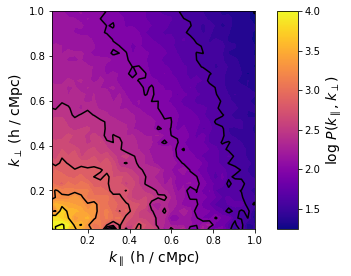

In [6]:
fig, axes = plt.subplots(1, 2, gridspec_kw = {'width_ratios':[1, .1], 'hspace':0.25}, figsize = (4.4, 4))
plot_pk(axes[0], axes[1], hidata_tng300, vlim = [1.25, 4], cmap = 'plasma')

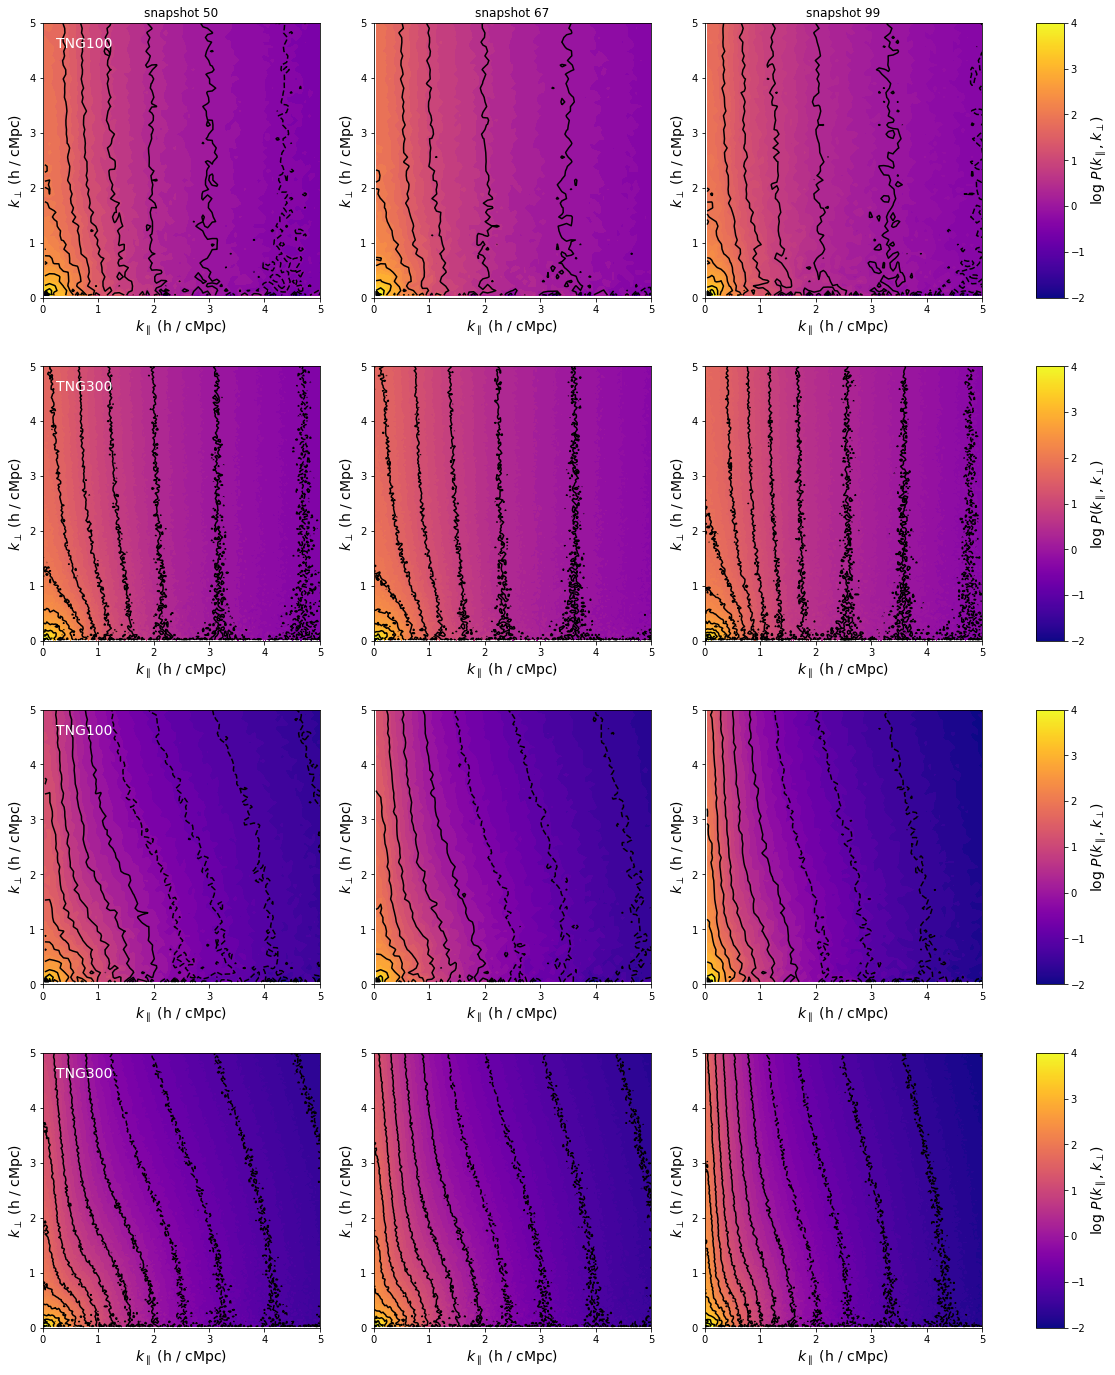

In [7]:
nrows = 4; ncols = 4
snapshots = [50, 67, 99]
fieldnames = ['vn', 'ptl']
boxes = [100, 300]
fig, axes = plt.subplots(nrows, ncols, gridspec_kw = {'width_ratios':[1, 1, 1, .1], 'hspace':0.25, 'wspace':0.25}, figsize = (18.3, 24))
rowidx = 0
for i in range(len(fieldnames)):
    for j in range(len(boxes)):
        for k in range(len(snapshots)):
            if fieldnames[i] == 'vn':
                rc = get_2dpk(boxes[j], snapshots[k], fieldnames[i])
            else:
                rc = get_2dpk(boxes[j], snapshots[k], fieldnames[i], ptl_species = 'ptl')
            plot_pk(axes[rowidx, k], axes[rowidx, -1], rc, vlim = [-2, 4], cmap = 'plasma', klim = [0, 5])
            if rowidx == 0:
                axes[rowidx, k].set_title('snapshot %d'%snapshots[k])
            if k == 0:
                axes[rowidx, k].text(0.05, 0.95, 'TNG%03d'%boxes[j], va = 'top', ha = 'left', fontsize = 14, color = 'white', transform = axes[rowidx, k].transAxes)
        rowidx += 1

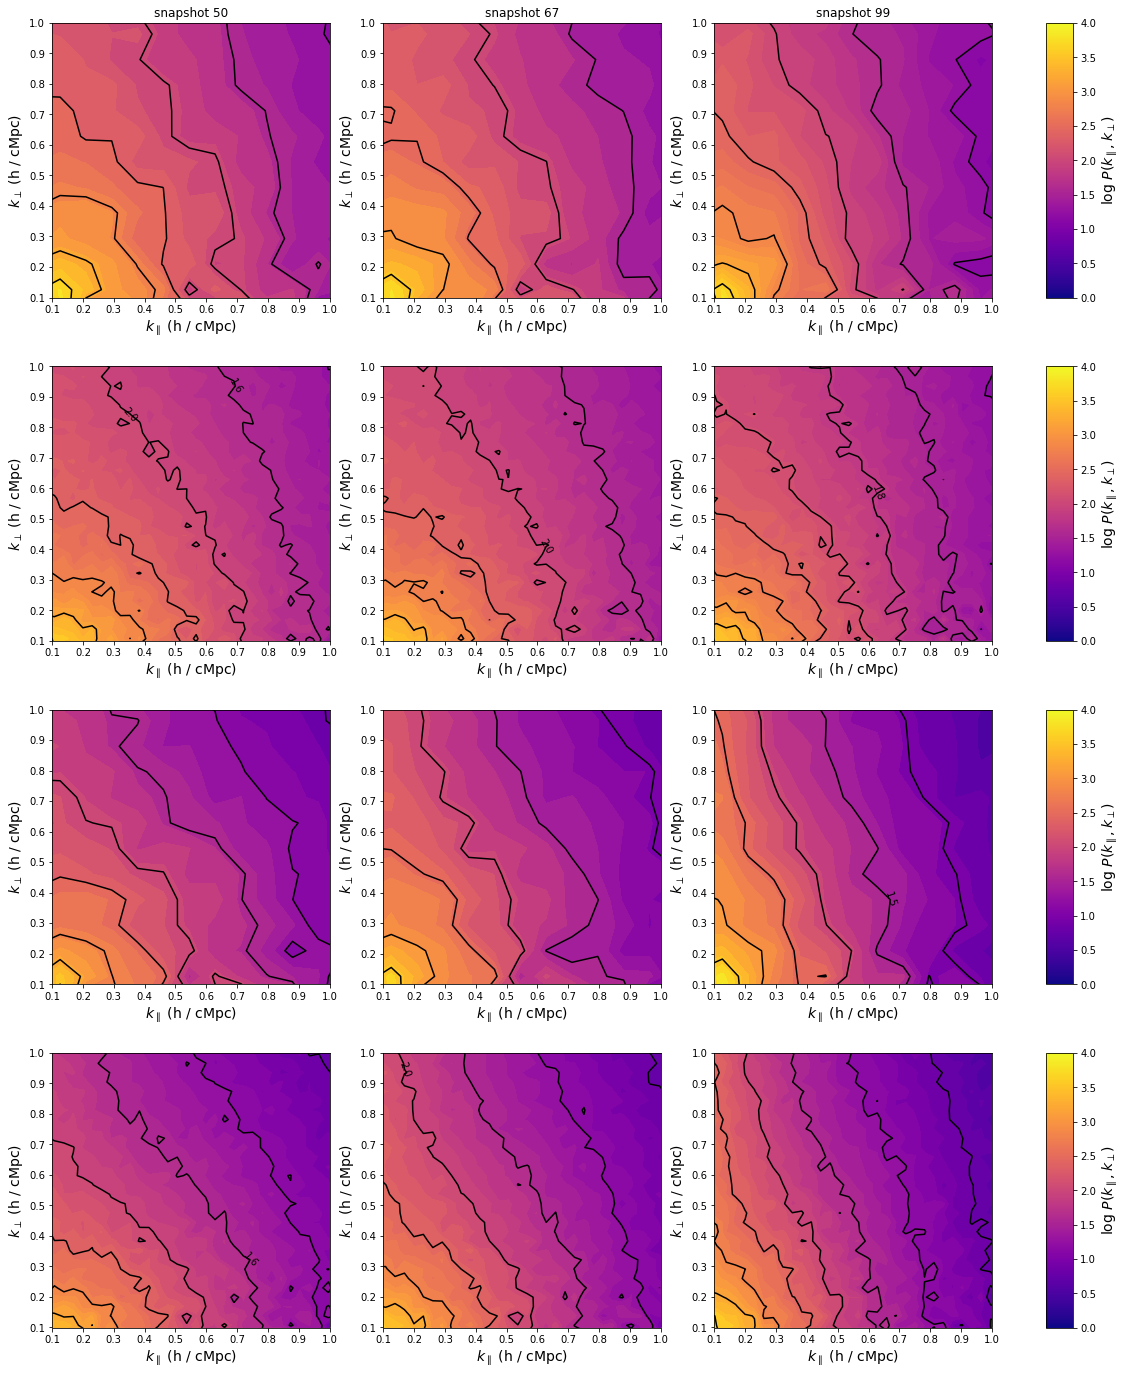

In [8]:
nrows = 4; ncols = 4
snapshots = [50, 67, 99]
fieldnames = ['vn', 'ptl']
boxes = [100, 300]
fig, axes = plt.subplots(nrows, ncols, gridspec_kw = {'width_ratios':[1, 1, 1, .1], 'hspace':0.25, 'wspace':0.25}, figsize = (18.3, 24))
rowidx = 0
for i in range(len(fieldnames)):
    for j in range(len(boxes)):
        for k in range(len(snapshots)):
            if fieldnames[i] == 'vn':
                rc = get_2dpk(boxes[j], snapshots[k], fieldnames[i])
            else:
                rc = get_2dpk(boxes[j], snapshots[k], fieldnames[i], ptl_species = 'ptl')
            plot_pk(axes[rowidx, k], axes[rowidx, -1], rc, vlim = [0, 4], cmap = 'plasma', klim = [0.1, 1], add_clabels = True)
            if rowidx == 0:
                axes[rowidx, k].set_title('snapshot %d'%snapshots[k])
        rowidx += 1

In [9]:

def get_levels(kvals, kpar):
    levels = []
    for k in kvals:
        idx = np.argmin(abs(kpar - k))
        levels.append(idx)
    return levels


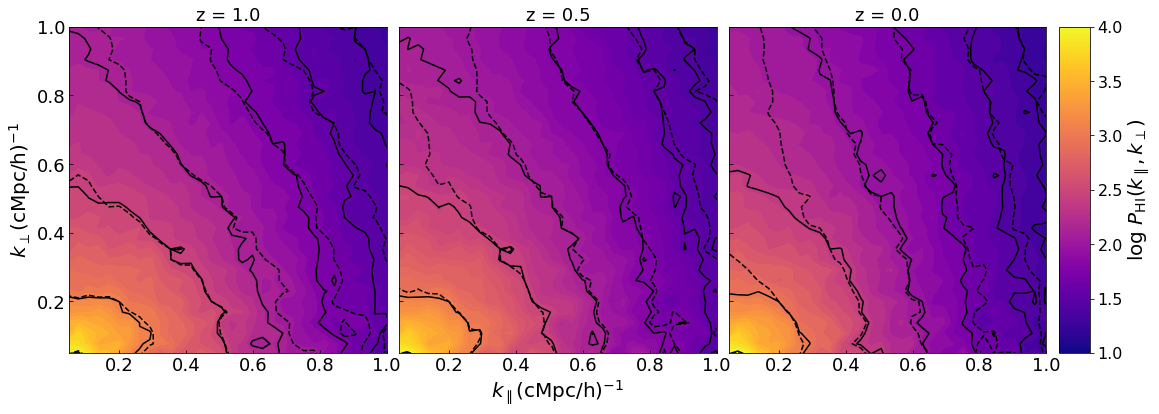

In [25]:
from scipy.ndimage.filters import gaussian_filter
gsigma = 0.5
nrows = 1; ncols = 4
vmin = 1; vmax = 4
kmin = 0.05; kmax = 1;
kvals = np.arange(kmin, kmax, 0.15)
snapshots = [50, 67, 99]
redshifts = [1, 0.5, 0]
fieldnames = ['vn', 'ptl']
fig, axes = plt.subplots(nrows, ncols, gridspec_kw = {'width_ratios':[1, 1, 1, .1], 'hspace':0.05, 'wspace':0.05}, figsize = (18.3, 6))
for k in range(len(snapshots)):
    vnrc = get_2dpk(300, snapshots[k], 'vn')
    ptlrc = get_2dpk(300, snapshots[k], 'ptl', ptl_species = 'ptl')

    kpar, kper, hipk = vnrc.getValues()
    kpar = np.unique(kpar)
    kper = np.unique(kper)
    KPAR, KPER = np.meshgrid(kpar, kper)
    hipk = np.reshape(hipk, KPAR.shape)
    
    kpar, kper, ptlpk = ptlrc.getValues()
    kpar = np.unique(kpar)
    kper = np.unique(kper)
    KPAR, KPER = np.meshgrid(kpar, kper)
    ptlpk = np.reshape(ptlpk, KPAR.shape)
    
    hipk = gaussian_filter(hipk, sigma = gsigma)
    ptlpk = gaussian_filter(ptlpk, sigma = gsigma)
    
    lev_idxs = get_levels(kvals, kpar)
    hilevs = np.log10(hipk[lev_idxs, lev_idxs])
    ptllevs = np.log10(ptlpk[lev_idxs, lev_idxs])

    plt.sca(axes[k])
    kwargs = {'cmap':'plasma', 'vmin':vmin, 'vmax':vmax}
    plt.contourf(KPAR, KPER, np.log10(hipk), levels = 100, **kwargs)

    plt.contour(KPAR, KPER, np.log10(hipk), levels = hilevs[::-1], colors = 'black', linestyles = 'solid')
    plt.contour(KPAR, KPER, np.log10(ptlpk), levels = ptllevs[::-1], colors = 'black', linestyles = 'dashed')
    if k == 0:
        norm = mpl.colors.Normalize(vmin, vmax)
        smap = mpl.cm.ScalarMappable(norm = norm, cmap = kwargs['cmap'])
        plt.colorbar(smap, cax = axes[-1])
        axes[-1].set_ylabel(r'log $P_{\mathrm{HI}}(k_\parallel, k_\perp)$', fontsize = 20)
    plt.xlim(kmin, kmax)
    plt.ylim(kmin, kmax)
    
    if k == 1:
        axes[k].set_xlabel(r'$k_\parallel (\mathrm{cMpc / h)}^{-1}$', fontsize = 20)
    if k == 0:
        axes[k].set_ylabel(r'$k_\perp (\mathrm{cMpc / h})^{-1}$', fontsize = 20)
    axes[k].tick_params(which = 'both', labelsize = 18, direction = 'in')
    axes[k].set_title("z = %.1f"%redshifts[k], fontsize = 18)
    if not k == 0:
        axes[k].tick_params(labelleft = False)
axes[-1].tick_params(which = 'both', labelsize = 16)
fig.savefig("allZ_smooth_hi_vs_matter.png", dpi = 300, bbox_inches = 'tight')

In [ ]:
def zoom_plot(snap):
    snap_idx = snapshots.index(snap)
    vnrc = get_2dpk(300, snap, 'vn')
    ptlrc = get_2dpk(300, snap, 'ptl', ptl_species = 'ptl')

    kpar, kper, hipk = vnrc.getValues()
    kpar = np.unique(kpar)
    kper = np.unique(kper)
    KPAR, KPER = np.meshgrid(kpar, kper)
    hipk = np.reshape(hipk, KPAR.shape)
    
    kpar, kper, ptlpk = ptlrc.getValues()
    kpar = np.unique(kpar)
    kper = np.unique(kper)
    KPAR, KPER = np.meshgrid(kpar, kper)
    ptlpk = np.reshape(ptlpk, KPAR.shape)
    
    hipk = gaussian_filter(hipk, sigma = gsigma)
    ptlpk = gaussian_filter(ptlpk, sigma = gsigma)
    
    lev_idxs = get_levels(kvals, kpar)
    hilevs = np.log10(hipk[lev_idxs, lev_idxs])
    ptllevs = np.log10(ptlpk[lev_idxs, lev_idxs])
    
    fig, axes = plt.subplots(2, 2, gridspec_kw = {'width_ratios':[1, .1], 'hspace':0.05, 'wspace':0.05},
                             figsize = (4.4, 8))
    